# 2.2 Formatos de datos

En este tutorial manipularemos la estructura de datos desde y hacia varios formatos: JSON, CSV, Parquet, GeoTIFF, GeoJSON, netCDF/HDF5 y Zarr. Al final, compararemos el tamaño en disco de los mismos datos en los distintos formatos.

Todos los archivos creados o descargados en este cuaderno van a una carpeta local `data/`.

🖥️ [**Diapositivas — Sesión 04 (mié 7 oct)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec04_meet_the_data.html)

In [1]:
import os

os.makedirs('data', exist_ok=True)

## JSON (JavaScript Object Notation)
JSON es un formato de datos ligero y legible por humanos, usado en aplicaciones web y en API para el intercambio de datos. JSON se usa para almacenar metadatos, archivos de configuración y conjuntos de datos pequeños, en particular al trabajar con aplicaciones web o al interactuar con API (por ejemplo, al consultar datos meteorológicos o información geoespacial desde una API).
Un ejemplo simple:
```json
{
    "location": "Yellowstone",
    "coordinates": {
        "latitude": 44.423691,
        "longitude": -110.588516
    },
    "elevation_m": 2399,
    "temperature_c": 22.5
}

```
La codificación de caracteres es UTF-8. Los tipos de datos en un archivo JSON pueden ser números, cadenas de texto, booleanos, arreglos, objetos (colecciones de pares nombre-valor) o nulos. Hay más información sobre JSON en el [curso de EarthDataScience](https://earthdatascience.org/courses/use-data-open-source-python/intro-to-apis/apis-in-python/).

En Python, un archivo JSON se crea con la biblioteca `json`:

In [2]:
import json

data = {
    "location": "Yellowstone",
    "coordinates": {"latitude": 44.423691, "longitude": -110.588516},
    "elevation_m": 2399,
    "temperature_c": 22.5
}

with open('data/data.json', 'w') as outfile:
    json.dump(data, outfile)

## Formatos de datos tabulares

Los datos tabulares son comunes en las geociencias. El formato *CSV* es un formato conveniente y legible por humanos para *conjuntos de datos pequeños*, que almacena los datos por filas. El formato *Parquet* es legible por máquina, columnar y comprimido, construido para *conjuntos de datos grandes*.

### **CSV (Comma-Separated Values, valores separados por comas)**:

CSV es un formato simple y muy extendido para datos tabulares, usado a menudo en geociencias para compartir y almacenar conjuntos de datos pequeños (por ejemplo, muestras de suelo, lecturas ambientales).
Almacena los datos como texto plano, lo que lo hace fácil de leer pero ineficiente para conjuntos de datos grandes. Lo más habitual es leerlo con ``pandas``.

In [3]:
import pandas as pd

# Build a small table and write it to a CSV file
df = pd.DataFrame({
    'station': ['RAIN', 'HELN', 'BAKR'],
    'temperature_c': [12.5, 10.1, 8.3],
    'precipitation_mm': [3.0, 1.2, 0.0],
})
df.to_csv('data/output.csv', index=False)

# Read it back
df = pd.read_csv('data/output.csv')
df

,station,temperature_c,precipitation_mm
0,RAIN,12.5,3.0
1,HELN,10.1,1.2
2,BAKR,8.3,0.0


### **Parquet**:
Parquet es un formato de almacenamiento binario y columnar, optimizado para la eficiencia, en particular con conjuntos de datos grandes. Se usa ampliamente en entornos de *big data* (por ejemplo, para almacenar imágenes satelitales o salidas de modelos climáticos).

In [4]:
# Writing the same table to a Parquet file
df.to_parquet('data/output.parquet', index=False)

# Reading the Parquet file
df_read = pd.read_parquet('data/output.parquet')
print(df_read)

  station  temperature_c  precipitation_mm
0    RAIN           12.5               3.0
1    HELN           10.1               1.2
2    BAKR            8.3               0.0


## Datos geoespaciales
Los formatos principales para datos geoespaciales en esta lección son:
- **GeoTIFF**: un estándar de metadatos que incrusta la información de georreferenciación en un archivo TIFF (Tagged Image File Format). El Cloud-Optimized GeoTIFF (COG) es una variante organizada para el acceso remoto.
- **GeoJSON**: un formato para codificar diversas estructuras de datos geográficos (puntos, líneas, polígonos) en JSON.

In [5]:
import folium
import geopandas as gpd
import h5py
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pooch
import rasterio
import xarray as xr

from folium.plugins import MarkerCluster
from rasterio.plot import show

## 1. Datos ráster

### 1.1 rasterio para leer GeoTIFF

Los datos ráster son cualquier dato en píxeles (o en malla) donde cada píxel está asociado a una ubicación geográfica específica. El valor de un píxel puede ser continuo (por ejemplo, la elevación) o categórico (por ejemplo, el uso del suelo).

El paquete de Python ``rasterio`` ([documentación](https://rasterio.readthedocs.io/en/latest/)) lee formatos como ``GeoTIFF``.

Vea materiales introductorios adicionales de [EarthDataScience](https://www.earthdatascience.org/courses/use-data-open-source-python/intro-raster-data-python/) y tutoriales del [GeoHackweek](https://geohackweek.github.io/raster/).

Descargaremos un ráster de topografía con relieve sombreado de [Natural Earth](https://www.naturalearthdata.com/downloads/50m-raster-data/50m-cross-blend-hypso/). El archivo se llama `HYP_50M_SR` y viene comprimido en ZIP. Usamos ``pooch`` para descargarlo en `data/` y descomprimirlo en un solo paso.

In [6]:
files = pooch.retrieve(
    url="https://naciscdn.org/naturalearth/50m/raster/HYP_50M_SR.zip",
    known_hash="sha256:de6faaee29c8707764852a36c0973aea184e8ec94b6eebf21d061c923c8025de",
    fname="HYP_50M_SR.zip",
    path="./data",
    processor=pooch.Unzip(extract_dir="HYP_50M_SR"),
)
tif_file = [f for f in files if f.endswith(".tif")][0]
print(tif_file)

/Users/marinedenolle/Dropbox/CLASSES/ESS490/curriculum-book/book/Chapter2-DataManipulation/data/HYP_50M_SR/HYP_50M_SR.tif


Ahora abramos el GeoTIFF con ``rasterio``.

In [7]:
elevation = rasterio.open(tif_file)

Un *dataset* de rasterio no es un archivo netCDF: no tiene `.variables`. En su lugar, almacena una o más *bandas*. Los atributos básicos son `.count` (número de bandas), `.width` y `.height` (dimensiones del ráster) y `.crs` (sistema de referencia de coordenadas).

In [8]:
print("number of bands:", elevation.count)
print("width :", elevation.width)
print("height:", elevation.height)
print("crs   :", elevation.crs)

number of bands: 3
width : 10800
height: 5400
crs   : EPSG:4326


In [9]:
elevation.indexes

(1, 2, 3)

¿Puede adivinar cómo obtener los tipos de datos de las bandas?

In [10]:
# type below
elevation.dtypes

('uint8', 'uint8', 'uint8')

Y los límites del conjunto de datos:

In [11]:
elevation.bounds

BoundingBox(left=-179.99999999999997, bottom=-89.99999999998201, right=179.99999999996405, top=90.0)

In [12]:
print(elevation.transform * (0, 0)) # North West corner
print(elevation.transform * (elevation.width, elevation.height)) # South East corner

(-179.99999999999997, 90.0)
(179.99999999996405, -89.99999999998201)


Cómo interpretar los datos: hay tres bandas, una por cada uno de los colores rojo, verde y azul:

In [13]:
print(elevation.colorinterp[0])
print(elevation.colorinterp[1])
print(elevation.colorinterp[2])

3
4
5


In [14]:
print(np.min(elevation.read(1)), np.max(elevation.read(1)))
print(np.min(elevation.read(2)), np.max(elevation.read(2)))
print(np.min(elevation.read(3)), np.max(elevation.read(3)))

59 255
79 255


75 255


`elevation.read(1)` devuelve la primera banda como un arreglo 2D de numpy. Grafiquémosla sola, y luego las tres bandas como una imagen a color.

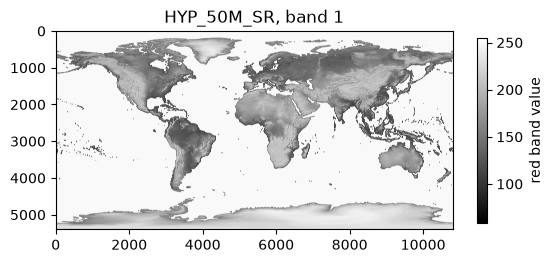

In [15]:
band1 = elevation.read(1)
plt.imshow(band1, cmap='gray')
plt.colorbar(shrink=0.5, label='red band value')
plt.title('HYP_50M_SR, band 1')
plt.show()

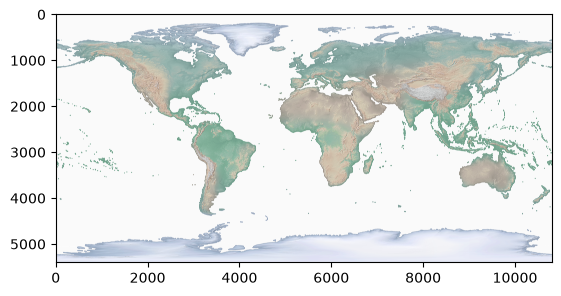

<Axes: >

In [16]:
image = elevation.read()
show(image)

### 1.2 Geopandas para leer GeoJSON

GeoJSON es un caso especial de JSON que almacena elementos geográficos (puntos, líneas, polígonos) con sus atributos. En lugar de descargar uno, construiremos un GeoJSON pequeño desde cero: una `FeatureCollection` de cuatro volcanes de la cordillera de las Cascadas. Esto muestra la estructura del formato de manera explícita.

In [17]:
volcanoes_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"name": "Mt Rainier", "elevation_m": 4392},
            "geometry": {"type": "Point", "coordinates": [-121.7603, 46.8523]},
        },
        {
            "type": "Feature",
            "properties": {"name": "Mt St Helens", "elevation_m": 2549},
            "geometry": {"type": "Point", "coordinates": [-122.1944, 46.1912]},
        },
        {
            "type": "Feature",
            "properties": {"name": "Mt Baker", "elevation_m": 3286},
            "geometry": {"type": "Point", "coordinates": [-121.8144, 48.7768]},
        },
        {
            "type": "Feature",
            "properties": {"name": "Glacier Peak", "elevation_m": 3213},
            "geometry": {"type": "Point", "coordinates": [-121.1132, 48.1125]},
        },
    ],
}

with open('data/cascade_volcanoes.geojson', 'w') as f:
    json.dump(volcanoes_geojson, f, indent=2)

Observe la estructura: cada `Feature` tiene una `geometry` (aquí un `Point`, con la longitud primero y la latitud después) y un diccionario `properties` para los atributos. Ahora leamos el archivo de vuelta con ``geopandas``:

In [18]:
volcanoes = gpd.read_file('data/cascade_volcanoes.geojson')
volcanoes

,name,elevation_m,geometry
0,Mt Rainier,4392,POINT (-121.7603 46.8523)
1,Mt St Helens,2549,POINT (-122.1944 46.1912)
2,Mt Baker,3286,POINT (-121.8144 48.7768)
3,Glacier Peak,3213,POINT (-121.1132 48.1125)


Geopandas interpretó la columna de geometría y fijó el sistema de referencia de coordenadas en WGS84 (EPSG:4326), el valor por defecto de GeoJSON:

In [19]:
volcanoes.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Grafiquemos los datos en un mapa interactivo. Folium es un buen paquete de Python para visualización. El [tutorial de Folium del Geohackweek](https://github.com/geohackweek/tutorial_contents/blob/master/visualization/notebooks/foliumTutorial.ipynb) también es informativo.

In [20]:
m = folium.Map(location=[47.5, -121.8], zoom_start=7)
marker_cluster = MarkerCluster().add_to(m)
for _, row in volcanoes.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=f"{row['name']}: {row['elevation_m']} m",
    ).add_to(marker_cluster)
m

## 2. Formatos jerárquicos: NETCDF4 y HDF5

Los formatos de datos jerárquicos están diseñados para almacenar grandes cantidades de datos en un solo archivo. Imitan un sistema de archivos (una estructura de datos en árbol con directorios anidados) dentro de un único archivo. Hay dos formatos jerárquicos dominantes (HDF5 y NETCDF4) y uno construido para la nube (Zarr). Los formatos jerárquicos pueden almacenar muchos tipos de datos (numéricos y de texto).

### HDF5
El Hierarchical Data Format versión 5 (HDF5) es un formato de archivo de código abierto que admite datos grandes, complejos y heterogéneos. HDF5 usa una estructura tipo "directorio de archivos" que permite organizar los datos dentro del archivo de muchas maneras estructuradas, como haría con los archivos de su computadora. El formato HDF5 también permite incrustar metadatos, lo que lo vuelve _autodescriptivo_. Todos los elementos (el archivo mismo, los grupos y los datasets) pueden llevar metadatos asociados que describen la información que contienen.

Ejemplo de estructura HDF:
- Datasets, que son arreglos multidimensionales tipados
- Grupos, que son estructuras contenedoras que pueden alojar datasets y otros grupos

<img src="hdf5_structure4.jpeg" alt="An illustration of a H5 data set " />
Figura: ejemplo de datos HDF5. Tomado de [neonscience](https://www.neonscience.org/resources/learning-hub/tutorials/about-hdf5)

### NetCDF

El network Common Data Form, o **netCDF**, se creó a comienzos de los años noventa para resolver algunos de los desafíos de trabajar con arreglos N-dimensionales. Netcdf es una colección de formatos binarios autodescriptivos e independientes de la máquina, junto con herramientas de software, que facilitan la creación, el acceso y el intercambio de datos científicos almacenados en arreglos N-dimensionales, con metadatos que describen el contenido de cada arreglo. Netcdf fue construido por la comunidad de ciencias del clima en una época en que los modelos climáticos regionales empezaban a producir archivos de salida cada vez más grandes. NetCDF versión 4 es un subconjunto de HDF5, así que los archivos netCDF4 pueden abrirse con herramientas de HDF5.

#### Manejo de arreglos grandes
Los formatos netCDF y HDF5 no tienen límite de tamaño de archivo. Sin embargo, cualquier herramienta de análisis que lea datos de un arreglo netCDF a memoria para alguna operación de cómputo está limitada por la memoria disponible de esa máquina en particular.

#### Pero lentos en E/S
Al leer un archivo jerárquico, se recorre todo el árbol de la estructura de datos desde el nodo raíz hacia abajo. Como esto debe hacerse cada vez que un usuario hace una consulta, leer HDF5 y netCDF es **lento** comparado con formatos diseñados para el acceso paralelo o en la nube.

### 2.1 Crear un conjunto de datos y escribirlo a netCDF

Creamos un campo sintético de anomalías mensuales de temperatura con el paquete del curso `mlgeo_synth`, conservamos un corte temporal como campo 2D y lo envolvemos en un Dataset de ``xarray`` con coordenadas y unidades.

In [21]:
import mlgeo_synth

field, truth = mlgeo_synth.climate_field(n_lat=40, n_lon=80, n_months=120, seed=42)
print(field.shape)  # (n_months, n_lat, n_lon)

(120, 40, 80)


In [22]:
ds = xr.Dataset(
    data_vars={
        "temperature_anomaly": (
            ("lat", "lon"),
            field[0],
            {"units": "degC", "long_name": "monthly temperature anomaly"},
        )
    },
    coords={
        "lat": ("lat", truth["lat"], {"units": "degrees_north"}),
        "lon": ("lon", truth["lon"], {"units": "degrees_east"}),
    },
    attrs={"title": "Synthetic temperature anomaly, month 0", "source": "mlgeo_synth.climate_field"},
)
ds

<xarray.Dataset> Size: 27kB
Dimensions:              (lat: 40, lon: 80)
Coordinates:
  * lat                  (lat) float64 320B -88.0 -83.49 -78.97 ... 83.49 88.0
  * lon                  (lon) float64 640B 0.0 4.5 9.0 ... 346.5 351.0 355.5
Data variables:
    temperature_anomaly  (lat, lon) float64 26kB 9.932 9.915 ... -10.37 -10.41
Attributes:
    title:    Synthetic temperature anomaly, month 0
    source:   mlgeo_synth.climate_field

In [23]:
ds.to_netcdf('data/temperature_anomaly.nc')

### 2.2 Leerlo de vuelta con xarray

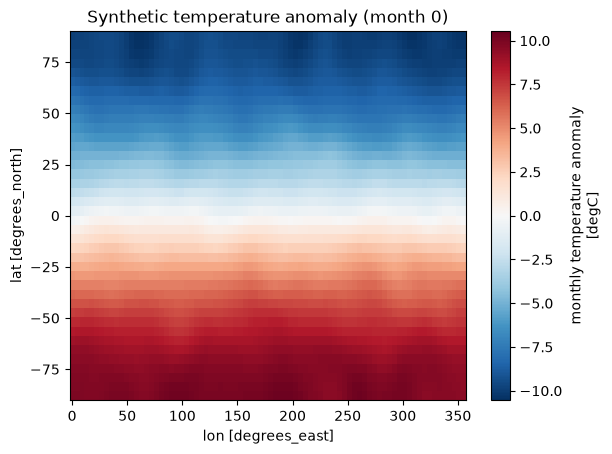

In [24]:
ds_read = xr.open_dataset('data/temperature_anomaly.nc')
ds_read.temperature_anomaly.plot()
plt.title('Synthetic temperature anomaly (month 0)')
plt.show()
ds_read.close()

### 2.3 El mismo archivo a través de las bibliotecas netCDF4 y h5py

La biblioteca `netCDF4` muestra la estructura autodescriptiva: dimensiones, variables y atributos.

In [25]:
geo = nc.Dataset('data/temperature_anomaly.nc')
print(geo)
print(geo['temperature_anomaly'])
geo.close()

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    title: Synthetic temperature anomaly, month 0
    source: mlgeo_synth.climate_field
    dimensions(sizes): lat(40), lon(80)
    variables(dimensions): float64 temperature_anomaly(lat, lon), float64 lat(lat), float64 lon(lon)
    groups: 
<class 'netCDF4.Variable'>
float64 temperature_anomaly(lat, lon)
    _FillValue: nan
    units: degC
    long_name: monthly temperature anomaly
unlimited dimensions: 
current shape = (40, 80)
filling on


Como los archivos netCDF4 son archivos HDF5, `h5py` puede abrir el mismo archivo. Las variables aparecen como datasets de HDF5, y los metadatos como atributos de HDF5.

In [26]:
with h5py.File('data/temperature_anomaly.nc', 'r') as f:
    print("datasets in the root group:", list(f.keys()))
    dset = f['temperature_anomaly']
    print("shape:", dset.shape, "dtype:", dset.dtype)
    print("attributes:", dict(dset.attrs))

datasets in the root group: ['temperature_anomaly', 'lat', 'lon']
shape: (40, 80) dtype: float64
attributes: {'_Netcdf4Coordinates': array([0, 1], dtype=int32), '_FillValue': array([nan]), 'units': np.bytes_(b'degC'), 'long_name': np.bytes_(b'monthly temperature anomaly'), 'DIMENSION_LIST': array([array([<HDF5 object reference>], dtype=object),
       array([<HDF5 object reference>], dtype=object)], dtype=object), '_Netcdf4Dimid': np.int32(0)}


## 3. Zarr

Zarr es un formato optimizado para la nube para arreglos N-dimensionales. En lugar de un archivo único, un *store* de Zarr es un directorio de fragmentos (*chunks*) comprimidos más pequeños archivos JSON de metadatos. Los almacenes de objetos en la nube y los trabajos paralelos pueden leer fragmentos individuales sin recorrer todo el árbol de archivos, lo que elimina el cuello de botella de E/S de netCDF/HDF5.

Xarray escribe a Zarr directamente:

In [27]:
ds.to_zarr('data/temperature_anomaly.zarr', mode='w')

/Users/marinedenolle/Dropbox/CLASSES/ESS490/curriculum-book/.pixi/envs/default/lib/python3.12/site-packages/zarr/api/asynchronous.py:246: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [28]:
ds_zarr = xr.open_zarr('data/temperature_anomaly.zarr')
ds_zarr

<xarray.Dataset> Size: 27kB
Dimensions:              (lat: 40, lon: 80)
Coordinates:
  * lat                  (lat) float64 320B -88.0 -83.49 -78.97 ... 83.49 88.0
  * lon                  (lon) float64 640B 0.0 4.5 9.0 ... 346.5 351.0 355.5
Data variables:
    temperature_anomaly  (lat, lon) float64 26kB dask.array<chunksize=(40, 80), meta=np.ndarray>
Attributes:
    title:    Synthetic temperature anomaly, month 0
    source:   mlgeo_synth.climate_field

El viaje de ida y vuelta preserva los datos y los metadatos:

In [29]:
np.allclose(ds_zarr.temperature_anomaly.values, ds.temperature_anomaly.values)

True

## 4. Comparación del tamaño en disco entre formatos

Ahora almacenamos los *mismos* datos en los formatos anteriores y comparamos sus tamaños en disco.
- Para la comparación de **tablas**, aplanamos el campo 2D a un dataframe (una fila por celda de la malla) y lo escribimos a CSV y a Parquet.
- Para la comparación de **arreglos**, usamos el archivo netCDF y el *store* de Zarr que ya escribimos. Un *store* de Zarr es un directorio, así que sumamos los tamaños de todos los archivos que contiene.

In [30]:
# Flatten the array to a table: one row per (lat, lon) grid cell
table = ds.temperature_anomaly.to_dataframe().reset_index()
table.to_csv('data/temperature_anomaly.csv', index=False)
table.to_parquet('data/temperature_anomaly.parquet', index=False)
table.head()

,lat,lon,temperature_anomaly
0,-88.0,0.0,9.932382
1,-88.0,4.5,9.914726
2,-88.0,9.0,9.873826
3,-88.0,13.5,9.813055
4,-88.0,18.0,9.761895


In [31]:
def path_size_bytes(path):
    """Size of a file, or the total size of all files under a directory."""
    if os.path.isfile(path):
        return os.path.getsize(path)
    total = 0
    for root, _, filenames in os.walk(path):
        for filename in filenames:
            total += os.path.getsize(os.path.join(root, filename))
    return total

sizes = {
    'CSV (table)': path_size_bytes('data/temperature_anomaly.csv'),
    'Parquet (table)': path_size_bytes('data/temperature_anomaly.parquet'),
    'netCDF (array)': path_size_bytes('data/temperature_anomaly.nc'),
    'Zarr (array)': path_size_bytes('data/temperature_anomaly.zarr'),
}
comparison = pd.DataFrame(
    {'size_kB': [v / 1024 for v in sizes.values()]},
    index=sizes.keys(),
).round(1)
print(comparison)

                 size_kB
CSV (table)        133.0
Parquet (table)     33.0
netCDF (array)      33.9
Zarr (array)        29.9


Interpretación: el archivo CSV es el más grande porque almacena cada número como texto, dígito por dígito. Parquet almacena la misma tabla en una disposición binaria comprimida y resulta varias veces más pequeño. El archivo netCDF y el *store* de Zarr contienen el mismo arreglo en forma binaria y quedan en el mismo rango de tamaño; la diferencia entre ellos a esta escala proviene de la sobrecarga del contenedor (encabezados HDF5 para netCDF, archivos de fragmentos y metadatos JSON para Zarr), no de los datos en sí. La brecha entre los formatos de texto y los binarios crece con el tamaño del conjunto de datos, y la disposición en fragmentos de Zarr rinde cuando muchos procesos leen a la vez piezas distintas de un arreglo grande.